In [11]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_all
from src.model import train_model, predict
from src.dare import dare_batch_fast, dare_batch_adaptive
from src.metrics import evaluate_dare

In [12]:
splits = load_all()
for name, (X, y) in splits.items():
    print(f"{name}: X={X.shape}, y={y.shape}")

X_train, y_train = splits["dTrain"]
model, scalers = train_model(X_train, y_train, epochs=200, verbose=False)

# Quick sanity check on train RMSE
y_hat = predict(model, X_train, scalers)
train_rmse = float(np.sqrt(np.mean((y_hat - y_train) ** 2)))
print(f"\nTrain RMSE: {train_rmse:.2f} °C")

dTrain: X=(250250, 2), y=(250250,)
dTest1: X=(340340, 2), y=(340340,)
dTest2: X=(340340, 2), y=(340340,)
dTest3: X=(340340, 2), y=(340340,)

Train RMSE: 0.52 °C


In [13]:
x_d = [20.0, 20.0, 20.0]   # v_T, T_UP, T_FCL bandwidths (paper's Setting b)
N = 3
tolerance = 10.0            # °C, paper's acceptance criterion

vanilla_rows = []
for name in ["dTest1", "dTest2", "dTest3"]:
    X_te, y_te = splits[name]
    y_hat = predict(model, X_te, scalers)

    padocs, accepted = dare_batch_fast(X_te, y_hat, X_train, y_train,
                                       x_d=x_d, N=N)
    m = evaluate_dare(y_hat, y_te, accepted, tolerance=tolerance)
    m["set"] = name
    vanilla_rows.append(m)
    print(f"{name}: f_degrade={m['f_degrade']:.3f}  f_peril={m['f_peril']:.3f}  "
          f"F1={m['F1']:.3f}  F_max={m['F_max']:.3f}")

vanilla_df = pd.DataFrame(vanilla_rows).set_index("set")

dTest1: f_degrade=0.000  f_peril=0.000  F1=1.000  F_max=1.000
dTest2: f_degrade=0.701  f_peril=0.512  F1=0.371  F_max=0.779
dTest3: f_degrade=0.563  f_peril=0.984  F1=0.032  F_max=0.061


In [14]:
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
adaptive_rows = []

for alpha in alphas:
    for name in ["dTest1", "dTest2", "dTest3"]:
        X_te, y_te = splits[name]
        y_hat = predict(model, X_te, scalers)

        padocs, accepted, s = dare_batch_adaptive(
            X_te, y_hat, X_train, y_train,
            x_d=x_d, N=N, alpha=alpha, max_scale=2.0
        )
        m = evaluate_dare(y_hat, y_te, accepted, tolerance=tolerance)
        m["set"] = name
        m["alpha"] = alpha
        m["mean_scale"] = float(np.mean(s))
        adaptive_rows.append(m)
        print(f"alpha={alpha:.2f}  {name}: "
              f"f_degrade={m['f_degrade']:.3f}  f_peril={m['f_peril']:.3f}  "
              f"F1={m['F1']:.3f}  <s>={m['mean_scale']:.2f}")
    print()

adaptive_df = pd.DataFrame(adaptive_rows)

alpha=0.00  dTest1: f_degrade=0.000  f_peril=0.000  F1=1.000  <s>=1.00
alpha=0.00  dTest2: f_degrade=0.701  f_peril=0.512  F1=0.371  <s>=1.00
alpha=0.00  dTest3: f_degrade=0.563  f_peril=0.984  F1=0.032  <s>=1.00

alpha=0.25  dTest1: f_degrade=0.000  f_peril=0.000  F1=1.000  <s>=1.64
alpha=0.25  dTest2: f_degrade=0.046  f_peril=0.370  F1=0.759  <s>=1.99
alpha=0.25  dTest3: f_degrade=0.051  f_peril=0.970  F1=0.058  <s>=1.94

alpha=0.50  dTest1: f_degrade=0.000  f_peril=0.000  F1=1.000  <s>=1.76
alpha=0.50  dTest2: f_degrade=0.046  f_peril=0.370  F1=0.759  <s>=2.00
alpha=0.50  dTest3: f_degrade=0.051  f_peril=0.970  F1=0.058  <s>=2.00

alpha=0.75  dTest1: f_degrade=0.000  f_peril=0.000  F1=1.000  <s>=1.82
alpha=0.75  dTest2: f_degrade=0.046  f_peril=0.370  F1=0.759  <s>=2.00
alpha=0.75  dTest3: f_degrade=0.051  f_peril=0.970  F1=0.058  <s>=2.00

alpha=1.00  dTest1: f_degrade=0.000  f_peril=0.000  F1=1.000  <s>=1.85
alpha=1.00  dTest2: f_degrade=0.046  f_peril=0.370  F1=0.759  <s>=2.00
al

In [15]:
# Just alpha=0 (vanilla) vs alpha=0.25 (adaptive sweet spot)
compare = adaptive_df[adaptive_df["alpha"].isin([0.0, 0.25])].copy()
pivot = compare.pivot(index="set", columns="alpha",
                     values=["f_degrade", "f_peril", "F1"])
print(pivot.round(3))
print()

# Delta
for name in ["dTest1", "dTest2", "dTest3"]:
    v = adaptive_df[(adaptive_df["set"]==name) & (adaptive_df["alpha"]==0.0)].iloc[0]
    a = adaptive_df[(adaptive_df["set"]==name) & (adaptive_df["alpha"]==0.25)].iloc[0]
    print(f"{name}: F1 {v['F1']:.3f} -> {a['F1']:.3f}  "
          f"(delta {a['F1']-v['F1']:+.3f})   "
          f"f_degrade {v['f_degrade']:.3f} -> {a['f_degrade']:.3f}   "
          f"f_peril {v['f_peril']:.3f} -> {a['f_peril']:.3f}")

       f_degrade        f_peril           F1       
alpha       0.00   0.25    0.00  0.25   0.00   0.25
set                                                
dTest1     0.000  0.000   0.000  0.00  1.000  1.000
dTest2     0.701  0.046   0.512  0.37  0.371  0.759
dTest3     0.563  0.051   0.984  0.97  0.032  0.058

dTest1: F1 1.000 -> 1.000  (delta +0.000)   f_degrade 0.000 -> 0.000   f_peril 0.000 -> 0.000
dTest2: F1 0.371 -> 0.759  (delta +0.388)   f_degrade 0.701 -> 0.046   f_peril 0.512 -> 0.370
dTest3: F1 0.032 -> 0.058  (delta +0.026)   f_degrade 0.563 -> 0.051   f_peril 0.984 -> 0.970


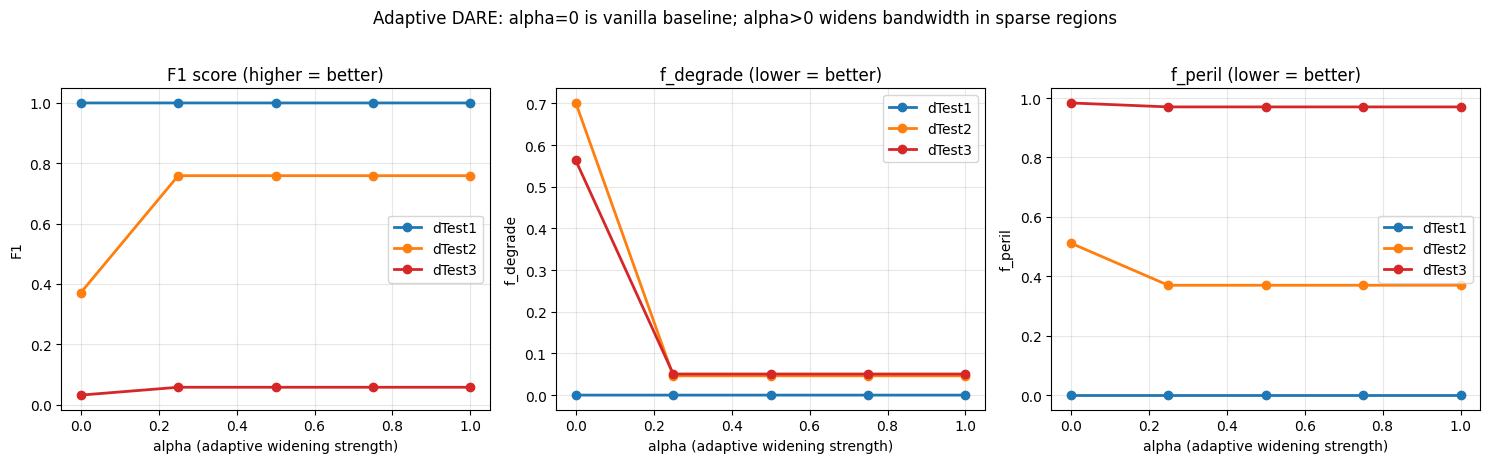

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics_to_plot = [("F1", "F1 score (higher = better)"),
                   ("f_degrade", "f_degrade (lower = better)"),
                   ("f_peril", "f_peril (lower = better)")]
colors = {"dTest1": "tab:blue", "dTest2": "tab:orange", "dTest3": "tab:red"}

for ax, (metric, title) in zip(axes, metrics_to_plot):
    for name in ["dTest1", "dTest2", "dTest3"]:
        sub = adaptive_df[adaptive_df["set"] == name].sort_values("alpha")
        ax.plot(sub["alpha"], sub[metric], marker="o", label=name,
                color=colors[name], linewidth=2)
    ax.set_xlabel("alpha (adaptive widening strength)")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Adaptive DARE: alpha=0 is vanilla baseline; alpha>0 widens bandwidth in sparse regions",
             y=1.02)
plt.tight_layout()
plt.savefig("../report_figs/alpha_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

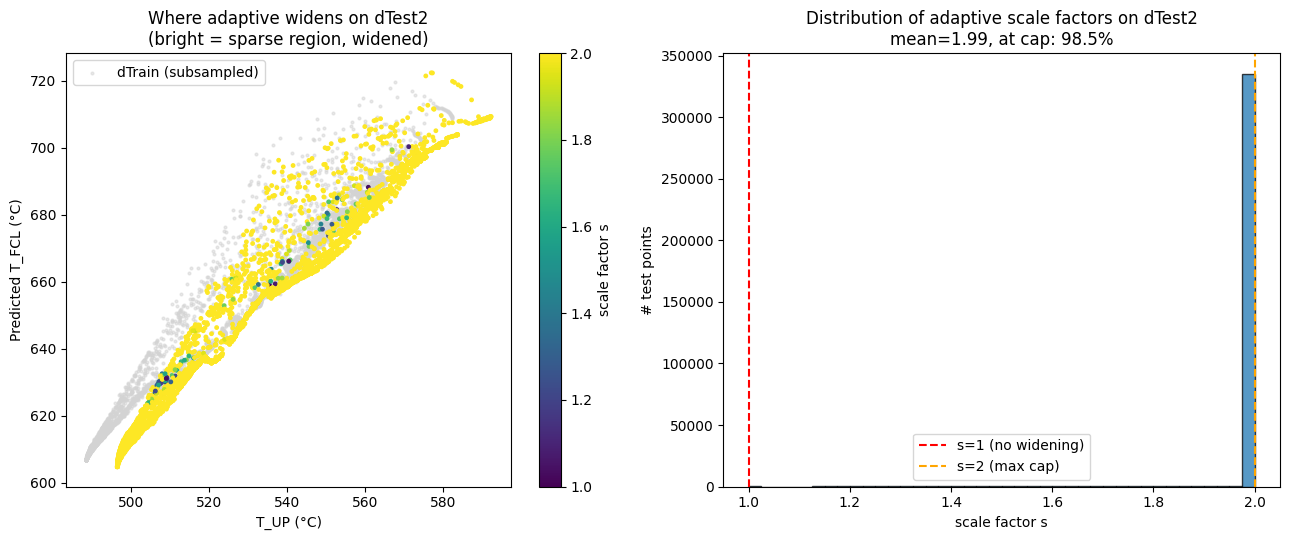

In [17]:
X_te, y_te = splits["dTest2"]
y_hat = predict(model, X_te, scalers)

# Recompute adaptive at sweet-spot alpha to get per-point scale factors
_, _, s_test = dare_batch_adaptive(
    X_te, y_hat, X_train, y_train,
    x_d=x_d, N=N, alpha=0.25, max_scale=2.0
)

# Subsample for a readable scatter (340k points would just be a blob)
rng = np.random.default_rng(0)
idx = rng.choice(len(X_te), size=8000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: training data (context) + test points colored by scale factor s
ax = axes[0]
ax.scatter(X_train[::50, 1], y_train[::50],
           s=4, c="lightgray", label="dTrain (subsampled)", alpha=0.5)
sc = ax.scatter(X_te[idx, 1], y_hat[idx], c=s_test[idx],
                cmap="viridis", s=6, vmin=1.0, vmax=2.0)
ax.set_xlabel("T_UP (°C)")
ax.set_ylabel("Predicted T_FCL (°C)")
ax.set_title("Where adaptive widens on dTest2\n(bright = sparse region, widened)")
plt.colorbar(sc, ax=ax, label="scale factor s")
ax.legend(loc="upper left")

# Right: histogram of scale factors
ax = axes[1]
ax.hist(s_test, bins=40, edgecolor="black", alpha=0.75)
ax.axvline(1.0, color="red", linestyle="--", label="s=1 (no widening)")
ax.axvline(2.0, color="orange", linestyle="--", label="s=2 (max cap)")
ax.set_xlabel("scale factor s")
ax.set_ylabel("# test points")
ax.set_title(f"Distribution of adaptive scale factors on dTest2\n"
             f"mean={s_test.mean():.2f}, at cap: {100*(s_test>=1.99).mean():.1f}%")
ax.legend()

plt.tight_layout()
plt.savefig("../report_figs/adaptive_scale_map.png", dpi=150, bbox_inches="tight")
plt.show()